In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/AppliedTimeSeriesAnalysisWithPython/main/data/jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [2]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [ ]:
# 마지막 4개 제외 모든 데이터
train = df[:-4]
# 마지막 4개만 포함
test = df[-4:]

# 과거 평균 기반 베이스라인

In [7]:
import numpy as np

historical_mean = np.mean(train['data'])

print(historical_mean)

4.308499987499999


In [ ]:
test.loc[:, 'pred_mean'] = historical_mean

## Test Accuracy

In [10]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [11]:
mape_hist_mean = mape(test['data'], test['pred_mean'])
print(mape_hist_mean)

70.00752579965119


# Visualize

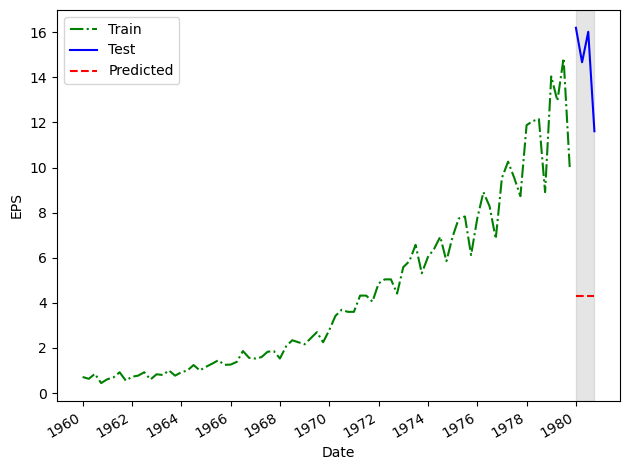

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label = 'Train')
ax.plot(test['date'], test['data'], 'b-', label = "Test")
ax.plot(test['date'], test['pred_mean'], 'r--', label = "Predicted")
ax.set_xlabel('Date')
ax.set_ylabel('EPS')
ax.axvspan(80, 83, color = '#808080', alpha = 0.2)
ax.legend(loc = 2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972,
                                1974, 1976, 1978, 1980])

# x축 눈금 레이블의 서식을 자동 설정; 레이블 약간 회전시켜 가독성 향상
fig.autofmt_xdate()
plt.tight_layout()

# 작년의 평균으로 예측

In [18]:
# 1979년 4번의 분기에 대한 EPS의 평균을 계산; train의 마지막 4개 요소의 평균 계산
last_year_mean = np.mean(train.data[-4:])

print(last_year_mean)

12.96


In [20]:
# pred__last_yr_mean 열 만들어 저장
test.loc[:, 'pred__last_yr_mean'] = last_year_mean

In [21]:
# MAPE 통해 베이스라인 재계산
mape_last_year_mean = mape(test['data'], test['pred__last_yr_mean'])

print(mape_last_year_mean)

15.5963680725103


## 시각화

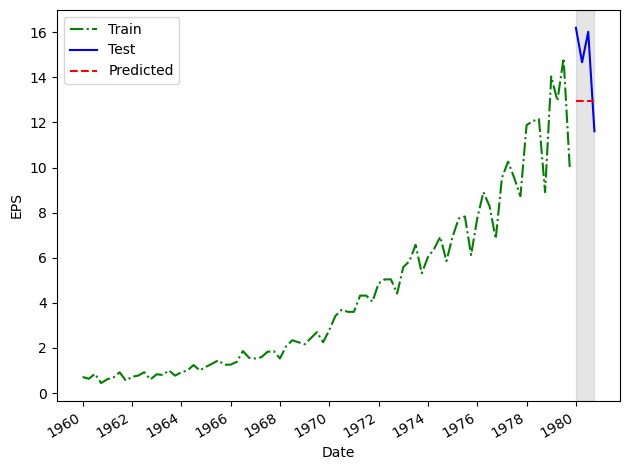

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label = 'Train')
ax.plot(test['date'], test['data'], 'b-', label = "Test")
#이제는 pred_mean이 아니라 pred__last_yr_mean
ax.plot(test['date'], test['pred__last_yr_mean'], 'r--', label = "Predicted")
ax.set_xlabel('Date')
ax.set_ylabel('EPS')
ax.axvspan(80, 83, color = '#808080', alpha = 0.2)
ax.legend(loc = 2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972,
                                1974, 1976, 1978, 1980])

# x축 눈금 레이블의 서식을 자동 설정; 레이블 약간 회전시켜 가독성 향상
fig.autofmt_xdate()
plt.tight_layout()

# 마지막으로 측정된 값으로 예측

In [ ]:
# 이전 베이스라인을 통해:
# "미랫값은 과거값과 연관이 있지만, '너무' 먼 과것값과는 연관성이 떨어진다"

# 그래서 train 데이터 중 마지막 값을 베이스라인 모델로 사용한다면?
# 가설: 더 나은 예측이 있지 않을까?

In [23]:
train

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61
...,...,...
75,1978-10-01,8.91
76,1979-01-01,14.04
77,1979-04-02,12.96
78,1979-07-02,14.85


In [ ]:
last = train.data.iloc[-1]

print(last)
# 가설에 배경하면, 1980년 4분기 EPS는 $9.99가 될것

9.99


In [26]:
# 예측값 저장
test.loc[:, 'pred_last'] = last